# Olist E-Commerce — Exploratory Data Analysis

**Author:** Swayam · **Stack:** Python · pandas · matplotlib · seaborn

This notebook walks through the data exploration that produced the project's six SQL analyses. It loads the raw CSVs and the pre-computed analysis outputs in `sql/outputs/` so it can be run without a Postgres dependency.

**Reading order:**
1. Data quality audit — what did I find before writing any SQL?
2. Volume & growth — does the dataset cover what it claims?
3. The late-delivery cliff — the headline finding.
4. Category economics — where does revenue come from?
5. Seller concentration — how Pareto is the marketplace?
6. Customer retention — is acquisition translating to repeat purchase?


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW  = ROOT / 'data' / 'raw'
OUT  = ROOT / 'sql' / 'outputs'

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 1. Data quality audit

First instinct on a new dataset: what's the size, the date range, the missing values, and where are the foot-guns?


In [2]:
files = {
    'customers':      'olist_customers_dataset.csv',
    'orders':         'olist_orders_dataset.csv',
    'order_items':    'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews':  'olist_order_reviews_dataset.csv',
    'products':       'olist_products_dataset.csv',
    'sellers':        'olist_sellers_dataset.csv',
    'translation':    'product_category_name_translation.csv',
    'geolocation':    'olist_geolocation_dataset.csv',
}
dfs = {k: pd.read_csv(RAW / v) for k, v in files.items()}

summary = pd.DataFrame({
    'rows': {k: len(v) for k, v in dfs.items()},
    'cols': {k: v.shape[1] for k, v in dfs.items()},
    'null_cols': {k: int((v.isnull().sum() > 0).sum()) for k, v in dfs.items()},
})
summary


,rows,cols,null_cols
customers,99441,5,0
orders,99441,8,3
order_items,112650,7,0
order_payments,103886,5,0
order_reviews,99224,7,2
products,32951,9,8
sellers,3095,4,0
translation,71,2,0
geolocation,1000163,5,0


**Findings from the audit:**

- `geolocation` has 1M rows for ~19K zip prefixes — multiple readings per zip, must be aggregated before joining.
- `order_reviews` has nulls in two text columns (titles, messages) but they're optional — only ~41% of customers leave written feedback.
- `products` has 610 rows with NULL category — small but meaningful (~R$140K GMV).
- `orders` has nulls in three timestamps (approved_at, carrier_date, customer_date) — corresponds to cancelled / in-transit / unfulfilled orders. **Important:** these can't be silently dropped from delivery analysis.


Date range:  2016-09-04 21:15:19  →  2018-10-17 17:30:18
Months with > 100 orders: 21
Months with < 100 orders: 4


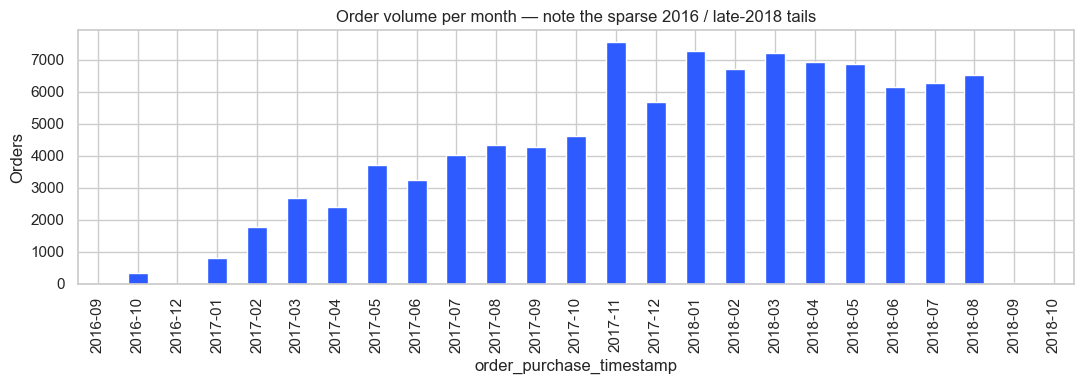

In [3]:
# Date range — the most important sanity check on a transactional dataset.
orders = dfs['orders'].copy()
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
monthly_volume = orders.groupby(orders['order_purchase_timestamp'].dt.to_period('M')).size()
print(f"Date range:  {orders['order_purchase_timestamp'].min()}  →  {orders['order_purchase_timestamp'].max()}")
print(f"Months with > 100 orders: {(monthly_volume > 100).sum()}")
print(f"Months with < 100 orders: {(monthly_volume <= 100).sum()}")

ax = monthly_volume.plot(kind='bar', figsize=(11, 4), color='#2E5BFF', edgecolor='white')
ax.set_title('Order volume per month — note the sparse 2016 / late-2018 tails')
ax.set_ylabel('Orders')
plt.tight_layout(); plt.show()


Sept 2016 has 4 orders, Dec 2016 has 1, Sept-Oct 2018 has 20 between them. Any time-series chart that includes these will be visually destroyed. The `in_analysis_window` flag in `v_orders_clean` truncates to **2017-01 → 2018-08** — 20 months of meaningful volume.


### The customer-id trap

`customer_id` looks like a person identifier — it isn't. It's a per-order surrogate. The actual person is `customer_unique_id`.


In [4]:
customers = dfs['customers']
n_unique     = customers['customer_unique_id'].nunique()
n_customer_id = customers['customer_id'].nunique()
repeated     = (customers.groupby('customer_unique_id').size() > 1).sum()
print(f'customer_id unique values:        {n_customer_id:>7,}')
print(f'customer_unique_id unique values: {n_unique:>7,}')
print(f'Repeat customers (≥2 orders):     {repeated:>7,}  ({repeated/n_unique*100:.2f}% of base)')


customer_id unique values:         99,441
customer_unique_id unique values:  96,096
Repeat customers (≥2 orders):       2,997  (3.12% of base)


**3.12% repeat rate.** Marketplace executives benchmark against 25–35%. This is the single most damning number in the dataset and the reason cohort retention gets its own analysis.


## 2. Volume & growth trajectory


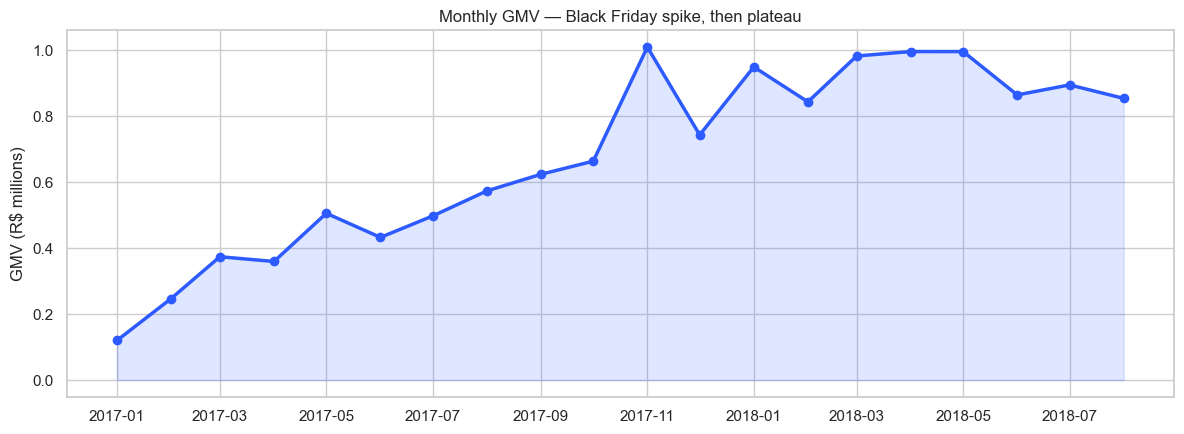

Total in-window GMV:  R$ 13.54M
Peak month:           2017-11  (R$ 1.01M)
AOV range:            R$ 125.48  →  R$ 152.49


In [5]:
trend = pd.read_csv(OUT / '07_monthly_revenue_trend.csv')
in_window = trend[trend['in_window'] == 't'].copy()
in_window['month_dt'] = pd.to_datetime(in_window['month'])

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(in_window['month_dt'], 0, in_window['gmv_brl']/1e6, color='#2E5BFF', alpha=0.15)
ax.plot(in_window['month_dt'], in_window['gmv_brl']/1e6, color='#2E5BFF', lw=2.5, marker='o')
ax.set_ylabel('GMV (R$ millions)'); ax.set_title('Monthly GMV — Black Friday spike, then plateau')
plt.tight_layout(); plt.show()

print(f"Total in-window GMV:  R$ {in_window['gmv_brl'].sum()/1e6:.2f}M")
print(f"Peak month:           {in_window.loc[in_window['gmv_brl'].idxmax(), 'month']}  (R$ {in_window['gmv_brl'].max()/1e6:.2f}M)")
print(f"AOV range:            R$ {in_window['aov_brl'].min():.2f}  →  R$ {in_window['aov_brl'].max():.2f}")


**Observation worth flagging:** GMV plateaus at ~R$ 950K/month from March 2018 onward. Six straight months of flat revenue is not a hyper-growth marketplace — it suggests the supply or demand side has saturated.


## 3. The late-delivery cliff


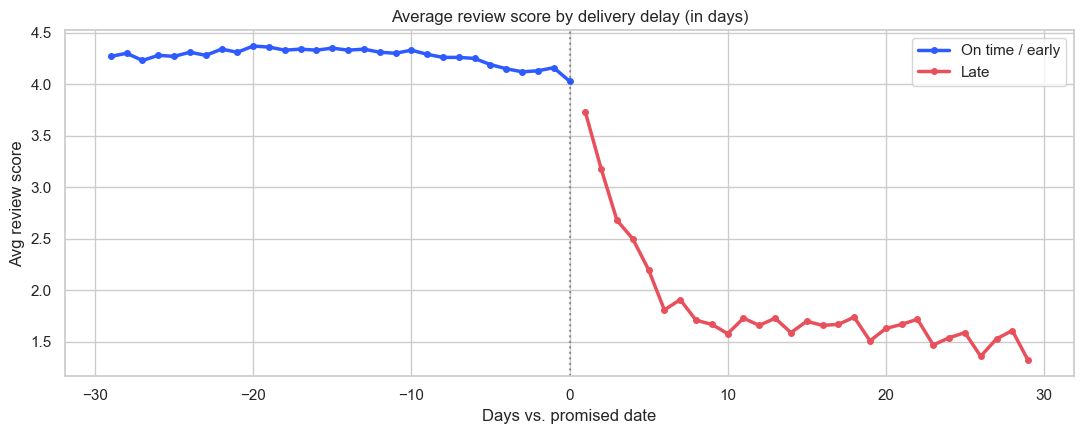

,delivery_status,orders,avg_review_score,pct_one_star,pct_five_star,pct_negative
0,on_time,87902,4.29,6.6,62.4,9.2
1,late,7658,2.57,46.2,22.3,54.0


In [6]:
delay = pd.read_csv(OUT / '04b_review_by_delay_bucket.csv')
delay = delay[(delay['delay_day_bucket'] > -30) & (delay['delay_day_bucket'] < 30)]

fig, ax = plt.subplots(figsize=(11, 4.5))
early = delay[delay['delay_day_bucket'] <= 0]
late  = delay[delay['delay_day_bucket'] >  0]
ax.plot(early['delay_day_bucket'], early['avg_review_score'], color='#2E5BFF', lw=2.5, marker='o', ms=4, label='On time / early')
ax.plot(late['delay_day_bucket'],  late['avg_review_score'],  color='#E8505B', lw=2.5, marker='o', ms=4, label='Late')
ax.axvline(0, color='#444', ls=':', alpha=0.5)
ax.set_xlabel('Days vs. promised date'); ax.set_ylabel('Avg review score')
ax.set_title('Average review score by delivery delay (in days)')
ax.legend(); plt.tight_layout(); plt.show()

ontime = pd.read_csv(OUT / '04a_review_by_ontime.csv')
ontime


The cliff is brutal:
- Day 0 (delivered exactly on time): 4.03 ★
- Day +1 (one day late): 3.73 ★ (already a 13% drop)
- Day +4: 2.50 ★
- Day +7: 1.91 ★, with 63% of customers leaving 1-star reviews

This means **'on-time delivery rate' should be Olist's #1 operational KPI**, not 'average delivery days'. A 9-day delivery that beats the promise gets a 4.3-star review; a 12-day delivery that misses a promise of 11 days gets a 2.7-star review.


## 4. Category economics


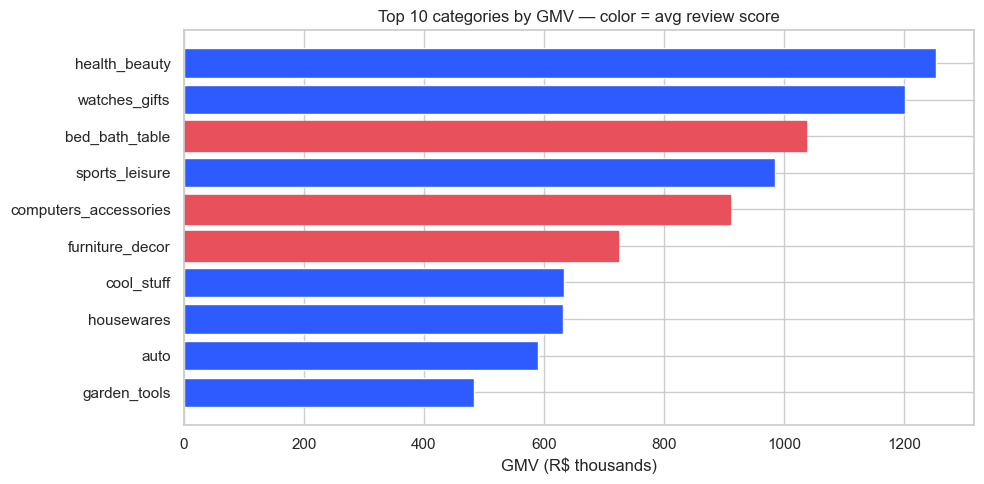

Top 3 categories share of GMV: 25.8%
Categories with avg review < 4.0: 25


In [7]:
cat = pd.read_csv(OUT / '03_revenue_by_category.csv')
top10 = cat.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['category'][::-1], top10['gmv_brl'][::-1]/1e3, color='#2E5BFF')
for b, score in zip(bars, top10['avg_review_score'][::-1]):
    if score < 4.0:   b.set_color('#E8505B')
    elif score >= 4.3: b.set_color('#27AE60')
ax.set_xlabel('GMV (R$ thousands)'); ax.set_title('Top 10 categories by GMV — color = avg review score')
plt.tight_layout(); plt.show()

print(f"Top 3 categories share of GMV: {cat.head(3)['pct_of_total_gmv'].sum():.1f}%")
print(f"Categories with avg review < 4.0: {(cat['avg_review_score'] < 4.0).sum()}")


## 5. Seller concentration


In [8]:
pareto = pd.read_csv(OUT / '06a_seller_pareto.csv')
pareto


,bucket,sellers,gmv_brl,pct_of_total_gmv
0,Top 1%,30,3477302.23,25.68
1,Top 5%,123,3718408.78,27.46
2,Top 10%,153,1928154.20,14.24
3,Top 25%,461,2659321.48,19.64
4,Top 50%,767,1318385.44,9.74
5,Bottom 50%,1534,440140.65,3.25


30 sellers (1% of the 3,095 active sellers) generate **25.7% of GMV**. The top 10% (306 cumulative) generate **67.4%**. The bottom 50% (1,534 sellers) generate just **3.2%**.

**Strategic implication:** A seller-success programme protecting the top 100 accounts has higher leverage than acquiring 1,000 long-tail sellers.


In [9]:
risk = pd.read_csv(OUT / '06c_risk_sellers.csv')
print(f'Risk sellers in top GMV quartile: {len(risk)}')
risk['risk_flag'].value_counts()


Risk sellers in top GMV quartile: 50


risk_flag
Low Reviews       40
Logistics Risk     5
Critical           5
Name: count, dtype: int64

## 6. Customer retention


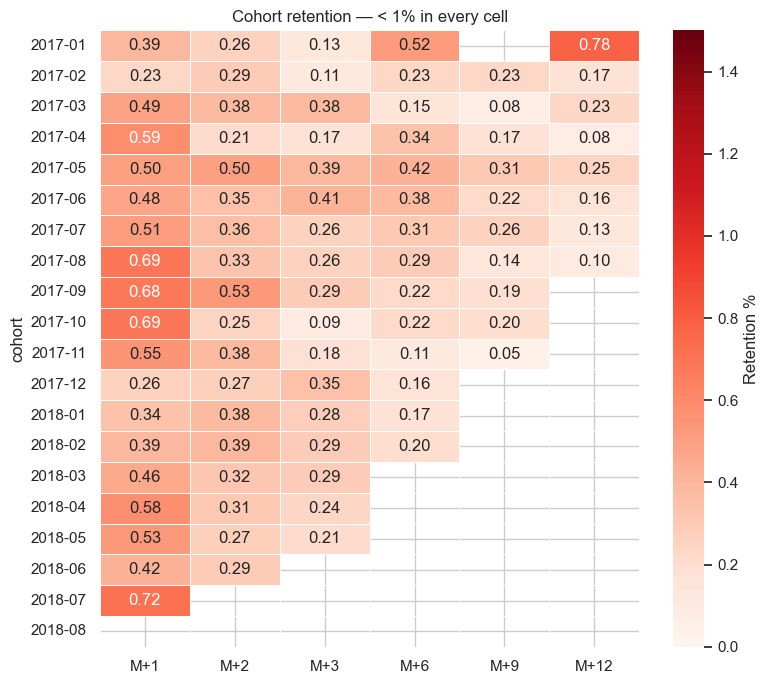

In [10]:
cohort = pd.read_csv(OUT / '08b_cohort_retention_pivot.csv').set_index('cohort')
matrix = cohort[['m1_pct','m2_pct','m3_pct','m6_pct','m9_pct','m12_pct']]
matrix.columns = ['M+1','M+2','M+3','M+6','M+9','M+12']

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1.5,
            cbar_kws={'label': 'Retention %'}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Cohort retention — < 1% in every cell')
plt.tight_layout(); plt.show()


In [11]:
rfm = pd.read_csv(OUT / '05a_rfm_segments.csv')
rfm.sort_values('segment_total_gmv', ascending=False)


,segment,customers,pct_of_base,avg_recency_days,avg_orders,avg_lifetime_gmv,segment_total_gmv,segment_share_of_gmv,avg_review_score
0,New & Promising,14902,15.6,94,1.00,267.97,3993307.36,29.5,4.10
1,High-Value Lost,11950,12.5,396,1.00,272.37,3254875.24,24.0,4.58
2,Need Attention,18523,19.3,222,1.00,128.83,2386282.72,17.6,3.95
3,Hibernating,23164,24.2,396,1.00,54.41,1260426.11,9.3,4.10
4,Recent One-Timers,22121,23.1,91,1.00,55.13,1219464.54,9.0,4.19
5,High-Value Burnt,2139,2.2,385,1.00,305.18,652789.05,4.8,1.20
6,Champions,985,1.0,90,2.20,329.68,324731.39,2.4,4.20
7,At Risk Repeaters,1056,1.1,383,2.08,251.23,265299.05,2.0,4.11
8,Loyal,934,1.0,177,2.07,197.58,184537.32,1.4,4.03


**The reactivation prize: High-Value Lost.** 11,950 customers, average lifetime spend R$ 272, average review score 4.58 ★, and 396 days since their last purchase. They liked Olist (4.58 ★) and they spent meaningfully (R$ 272). They simply have not returned. A targeted win-back campaign here is the single most economically rational marketing move suggested by this dataset.


---
## Closing summary

Three things to remember:
1. **The cliff is the story.** Operations should optimise for hitting the promised date, not for raw speed. Padding the estimate is a feature, not a bug.
2. **30 sellers carry 26% of GMV.** Protect them. The risk-seller list (`06c_risk_sellers.csv`) is the supplier-success backlog.
3. **Olist is a single-purchase funnel.** Until M+1 retention crosses 5%, growth depends entirely on top-of-funnel ad spend — which compounds CAC pressure as Brazil's e-commerce ad market matures.
